<a href="https://colab.research.google.com/github/hyunkyung31/DeepLearningProject/blob/main/hyunkyung/%ED%98%84%EA%B2%BD_%EC%BD%94%EB%93%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import zipfile
import os

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
zip_path = '/content/drive/MyDrive/🐥new_2_project/04_DL_project/02_dataset/CADICA.zip'
extract_path = '/content/cadica_dataset/'

if os.path.exists(zip_path) :
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f'압축 해제 완료, 저장위치 : {extract_path}')
else :
    print(f'에러 {zip_path}에 파일이 존재하지 않습니다')

압축 해제 완료, 저장위치 : /content/cadica_dataset/


In [ ]:
import glob

print('CDICA 데이터셋 검증')
base_dirs = os.listdir(extract_path)
print(f'최상위 디렉토리 구조 : {base_dirs}')

image_extensions = ['*.png', '*.jpg', '*.jpeg']
all_images = []
for ext in image_extensions :
    all_images.extend(glob.glob(os.path.join(extract_path, '**', ext), recursive=True))
print(f'시스템 내 감지된 총 이미지 프레임 수 : {len(all_images)} 장')

txt_files = glob.glob(os.path.join(extract_path, '**', '*.txt'), recursive=True)
print(f'시스템 내 감지된 labeling 관련 텍스트 파일 수 : {len(txt_files)} 개')

if txt_files :
    print(f'샘플 정답 파일 구조 확인 - {os.path.basename(txt_files[0])}')
    with open(txt_files[0], 'r') as f:
        lines = f.readlines()[:5]
        for line in lines :
            print(f' {line.strip()}')
else :
    print('경고 : 정답 라벨링을 위한 .txt파일을 찾지 못했습니다')

CDICA 데이터셋 검증
최상위 디렉토리 구조 : ['CADICA']
시스템 내 감지된 총 이미지 프레임 수 : 31500 장
시스템 내 감지된 labeling 관련 텍스트 파일 수 : 4463 개
샘플 정답 파일 구조 확인 - readme.txt
 Please cite the following paper when using CADICA:
 Jiménez‐Partinen, A., Molina‐Cabello, M. A., Thurnhofer‐Hemsi, K., Palomo, E. J., Rodríguez‐Capitán, J., Molina‐Ramos, A. I., & Jiménez‐Navarro, M. (2024). CADICA: A new dataset for coronary artery disease detection by using invasive coronary angiography. Expert Systems, 41(12), e13708.
 
 The CADICA dataset is an annotated dataset of Invasive Coronary Angiography (ICA) images from 42 patients, including manually labeled lesion bounding boxes and selected clinical features. In ICA imaging, lesion degree assessment is commonly visually estimated, which implies a subjective factor and interobserver variability. Accurate identification of lesions is crucial for correct diagnoses and treatment. This motivates the development of computer-aided systems that can support specialists in their clinical proc

In [ ]:
from pathlib import Path

base = Path("/content/cadica_dataset/CADICA/selectedVideos")

# 환자 폴더 하나 (예: p1)
patient_dirs = sorted([p for p in base.iterdir() if p.is_dir() and p.name.startswith("p")])
print("환자 수:", len(patient_dirs))
print("첫 환자:", patient_dirs[0])

p_dir = patient_dirs[0]
video_dirs = sorted([v for v in p_dir.iterdir() if v.is_dir() and v.name.startswith("v")])
print("영상 폴더:", video_dirs[0])

input_dir = video_dirs[0] / "input"
png_files = sorted(input_dir.glob("*.png"))[:5]  # 5장만!
for f in png_files:
    print(f.name)

환자 수: 42
첫 환자: /content/cadica_dataset/CADICA/selectedVideos/p1
영상 폴더: /content/cadica_dataset/CADICA/selectedVideos/p1/v1
p1_v1_00001.png
p1_v1_00002.png
p1_v1_00003.png
p1_v1_00004.png
p1_v1_00005.png


In [ ]:
gt_dir = video_dirs[0] / "groundtruth"
print("groundtruth 있음:", gt_dir.exists())
if gt_dir.exists():
    print("라벨 파일 예시:", list(gt_dir.glob("*.txt"))[:3])

groundtruth 있음: False


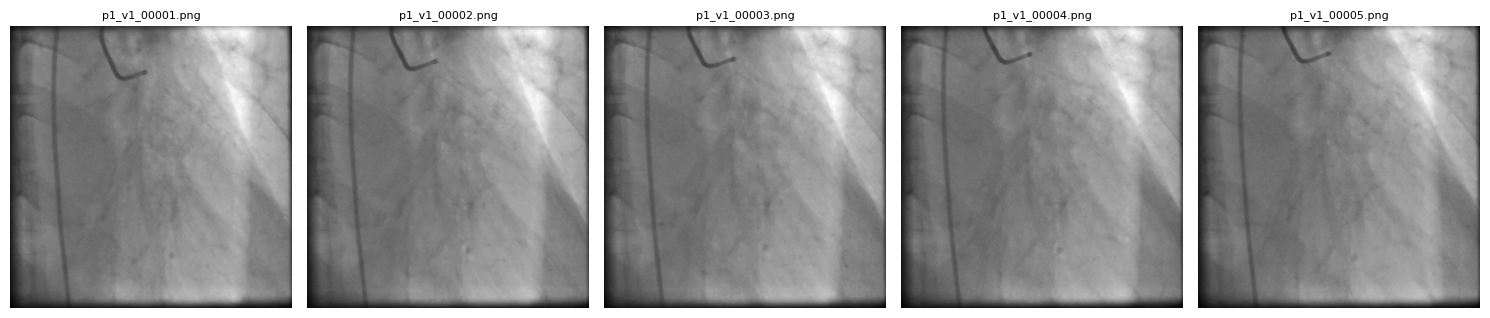

In [ ]:
import cv2
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(png_files), figsize=(15, 4))
if len(png_files) == 1:
    axes = [axes]

for ax, img_path in zip(axes, png_files):
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    ax.imshow(img, cmap='gray')
    ax.set_title(img_path.name, fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
from pathlib import Path

video_dir = Path("/content/cadica_dataset/CADICA/selectedVideos/p1/v1")
input_dir = video_dir / "input"

# keyframe 목록 (있으면 이걸 써야 함!)
sf = list(video_dir.glob("*selectedFrames.txt"))
print("selectedFrames 파일:", sf)

if sf:
    with open(sf[0]) as f:
        frames = [line.strip() for line in f if line.strip()]
    print("선택된 프레임 수:", len(frames))
    print("예시:", frames[:10])

selectedFrames 파일: [PosixPath('/content/cadica_dataset/CADICA/selectedVideos/p1/v1/p1_v1_selectedFrames.txt')]
선택된 프레임 수: 27
예시: ['p1_v1_00026', 'p1_v1_00027', 'p1_v1_00028', 'p1_v1_00029', 'p1_v1_00030', 'p1_v1_00031', 'p1_v1_00032', 'p1_v1_00033', 'p1_v1_00034', 'p1_v1_00035']


In [ ]:
p1_dir = Path("/content/cadica_dataset/CADICA/selectedVideos/p1")

print("=== lesion 영상 ===")
if (p1_dir / "lesionVideos.txt").exists():
    print((p1_dir / "lesionVideos.txt").read_text())

print("=== non-lesion 영상 ===")
if (p1_dir / "nonlesionVideos.txt").exists():
    print((p1_dir / "nonlesionVideos.txt").read_text())

=== lesion 영상 ===
v2
v3
v10
v11

=== non-lesion 영상 ===
v1
v4
v5
v6
v9
v12
v13
v14



총 프레임 수: 55


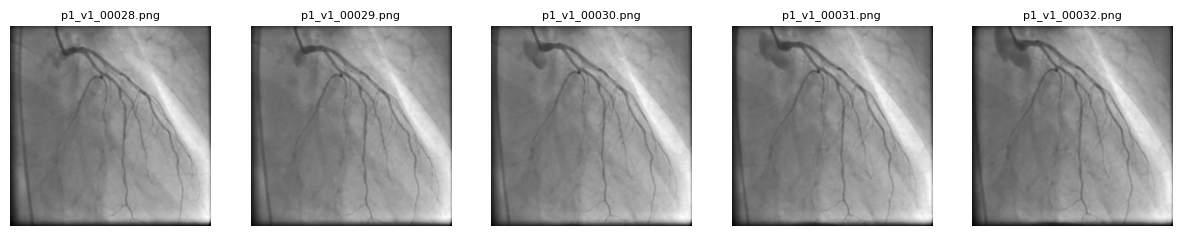

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

all_pngs = sorted(input_dir.glob("*.png"))
print("총 프레임 수:", len(all_pngs))

# 방법 A: 영상 중간~뒤쪽 샘플
sample_paths = all_pngs[len(all_pngs)//2 : len(all_pngs)//2 + 5]

# 방법 B: selectedFrames가 있으면 그걸로 (주석 해제)
# frame_ids = [int(x) for x in frames[:5]]
# sample_paths = [input_dir / f"p1_v1_{fid:05d}.png" for fid in frame_ids]

fig, axes = plt.subplots(1, len(sample_paths), figsize=(15, 4))
for ax, p in zip(axes, sample_paths):
    img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
    ax.imshow(img, cmap='gray')
    ax.set_title(p.name, fontsize=8)
    ax.axis('off')
plt.show()

In [ ]:
base = Path("/content/cadica_dataset/CADICA/selectedVideos")

for p_dir in sorted(base.glob("p*"))[:5]:
    lesion_file = p_dir / "lesionVideos.txt"
    if not lesion_file.exists():
        continue
    lesion_vids = lesion_file.read_text().strip().split()
    if not lesion_vids:
        continue

    v_name = lesion_vids[0].strip()   # 이미 "v2" 형태이므로 그대로 사용
    v_dir = p_dir / v_name

    if not v_dir.exists():
        print(f"{p_dir.name}/{v_name} | 폴더 없음 (경로 확인 필요)")
        continue

    gt_exists = (v_dir / "groundtruth").exists()
    input_dir = v_dir / "input"
    n_png = len(list(input_dir.glob("*.png"))) if input_dir.exists() else 0

    print(f"{p_dir.name}/{v_name} | png:{n_png} | groundtruth:{gt_exists}")

p1/v2 | png:56 | groundtruth:True
p10/v1 | png:51 | groundtruth:True
p11/v3 | png:51 | groundtruth:True
p12/v1 | png:49 | groundtruth:True
p13/v1 | png:52 | groundtruth:True


In [ ]:
gt_dir = Path("/content/cadica_dataset/CADICA/selectedVideos/p1/v2/groundtruth")
gt_files = sorted(gt_dir.glob("*.txt"))
print("라벨 파일 수:", len(gt_files))
print("예시:", gt_files[:3])

# 라벨 내용 확인 (bbox: x y w h category)
print(gt_files[0].read_text())

라벨 파일 수: 13
예시: [PosixPath('/content/cadica_dataset/CADICA/selectedVideos/p1/v2/groundtruth/p1_v2_00015.txt'), PosixPath('/content/cadica_dataset/CADICA/selectedVideos/p1/v2/groundtruth/p1_v2_00016.txt'), PosixPath('/content/cadica_dataset/CADICA/selectedVideos/p1/v2/groundtruth/p1_v2_00017.txt')]
257 123 42 55 p0_20



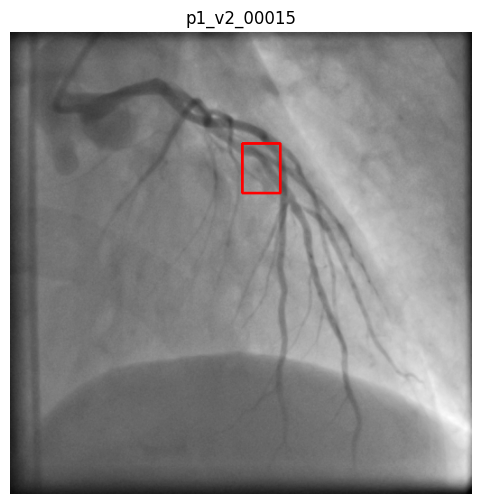

In [ ]:
import re

sample_gt = gt_files[0]
frame_id = sample_gt.stem  # 예: "p1_v2_00023"
img_path = Path("/content/cadica_dataset/CADICA/selectedVideos/p1/v2/input") / f"{frame_id}.png"

img = cv2.imread(str(img_path))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

with open(sample_gt) as f:
    for line in f:
        parts = line.strip().split()
        x, y, w, h = map(int, parts[:4])
        cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (255, 0, 0), 2)

plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.title(frame_id)
plt.axis('off')
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


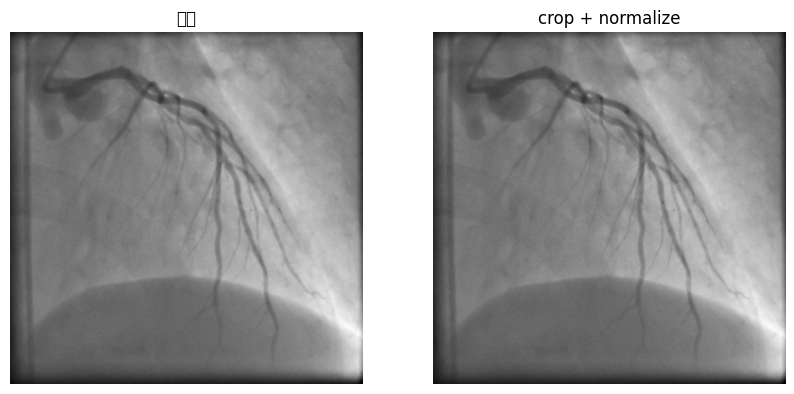

In [ ]:
import numpy as np

def simple_preprocess(gray):
    # 1) 검은 여백 제거
    ys, xs = np.where(gray > 10)
    if len(xs) == 0:
        return gray
    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()
    cropped = gray[y1:y2+1, x1:x2+1]

    # 2) 0~1 normalize
    cropped = cropped.astype(np.float32)
    cropped = (cropped - cropped.min()) / (cropped.max() - cropped.min() + 1e-8)
    return cropped

gray = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
proc = simple_preprocess(gray)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gray, cmap='gray')
axes[0].set_title("원본")
axes[0].axis('off')

axes[1].imshow(proc, cmap='gray')
axes[1].set_title("crop + normalize")
axes[1].axis('off')
plt.show()

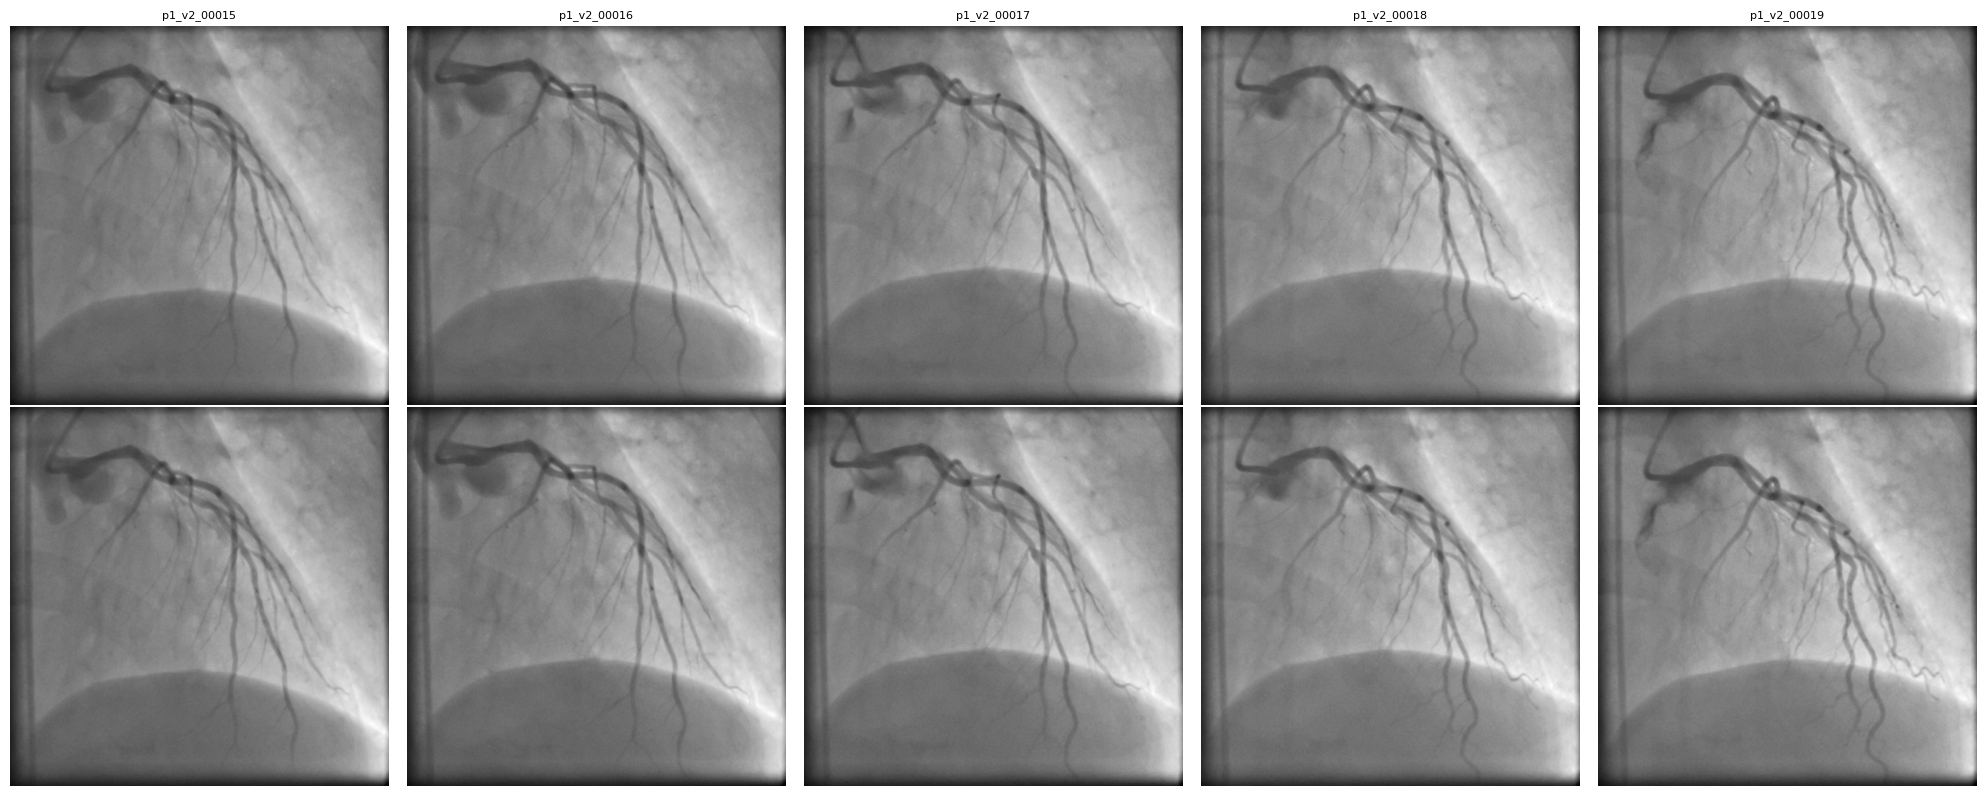

In [ ]:
gt_files_5 = gt_files[:5]

fig, axes = plt.subplots(2, len(gt_files_5), figsize=(4*len(gt_files_5), 8))

for i, gt_file in enumerate(gt_files_5):
    fid = gt_file.stem
    ip = Path("/content/cadica_dataset/CADICA/selectedVideos/p1/v2/input") / f"{fid}.png"
    g = cv2.imread(str(ip), cv2.IMREAD_GRAYSCALE)
    p = simple_preprocess(g)

    axes[0, i].imshow(g, cmap='gray')
    axes[0, i].set_title(fid, fontsize=8)
    axes[0, i].axis('off')

    axes[1, i].imshow(p, cmap='gray')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


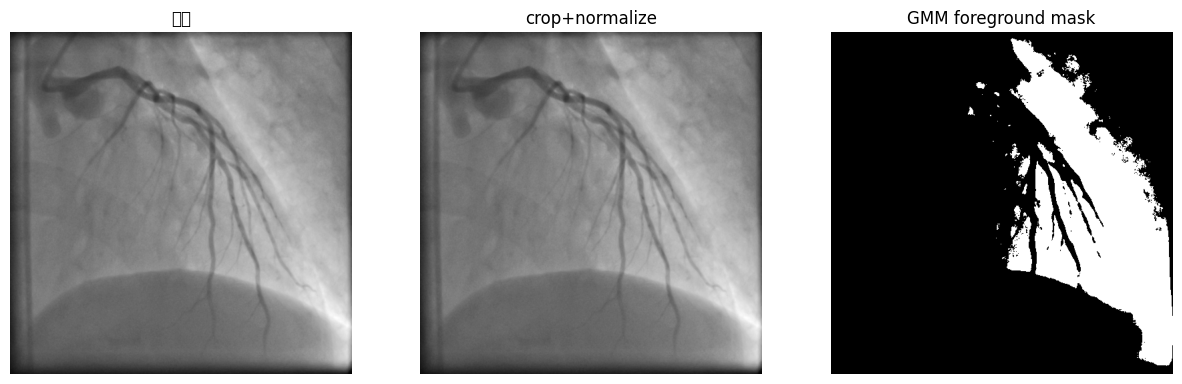

In [ ]:
from sklearn.mixture import GaussianMixture

def apply_gmm(proc_img, n_components=2):
    h, w = proc_img.shape
    pixels = proc_img.reshape(-1, 1)  # 픽셀값만으로 clustering

    gmm = GaussianMixture(n_components=n_components, random_state=0)
    labels = gmm.fit_predict(pixels)

    # 밝은 쪽 cluster를 "foreground(혈관)"로 간주
    means = gmm.means_.flatten()
    fg_cluster = np.argmax(means)

    mask = (labels == fg_cluster).reshape(h, w)
    return mask, gmm

mask, gmm = apply_gmm(proc)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(gray, cmap='gray')
axes[0].set_title("원본")
axes[0].axis('off')

axes[1].imshow(proc, cmap='gray')
axes[1].set_title("crop+normalize")
axes[1].axis('off')

axes[2].imshow(mask, cmap='gray')
axes[2].set_title("GMM foreground mask")
axes[2].axis('off')
plt.show()

In [ ]:
plt.rcParams['font.family'] = 'DejaVu Sans'
# 또는 title을 영어로만 쓰기

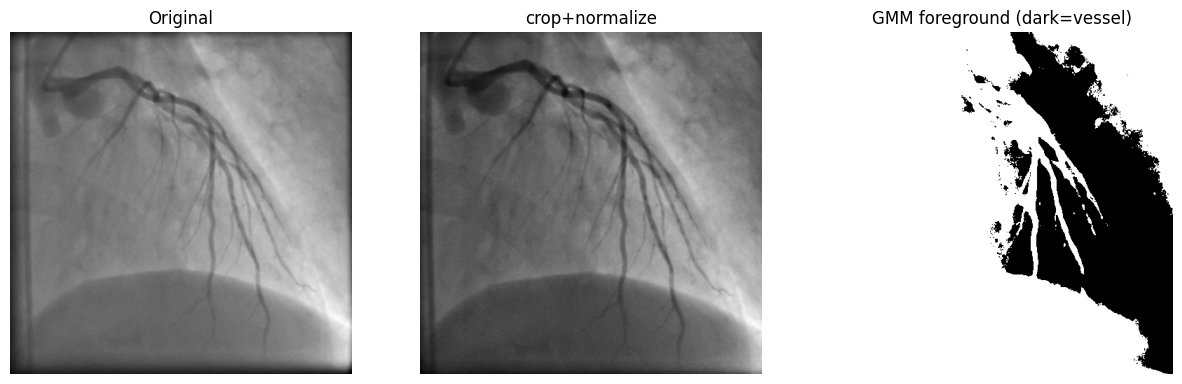

In [ ]:
def apply_gmm(proc_img, n_components=2):
    h, w = proc_img.shape
    pixels = proc_img.reshape(-1, 1)

    gmm = GaussianMixture(n_components=n_components, random_state=0)
    labels = gmm.fit_predict(pixels)

    means = gmm.means_.flatten()
    fg_cluster = np.argmin(means)   # ★ 어두운 쪽 = 혈관

    mask = (labels == fg_cluster).reshape(h, w)
    return mask, gmm

mask, gmm = apply_gmm(proc)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(gray, cmap='gray'); axes[0].set_title("Original"); axes[0].axis('off')
axes[1].imshow(proc, cmap='gray'); axes[1].set_title("crop+normalize"); axes[1].axis('off')
axes[2].imshow(mask, cmap='gray'); axes[2].set_title("GMM foreground (dark=vessel)"); axes[2].axis('off')
plt.show()

cluster 평균 밝기 (어두운→밝은): [0.26700019 0.3858581  0.60341929]


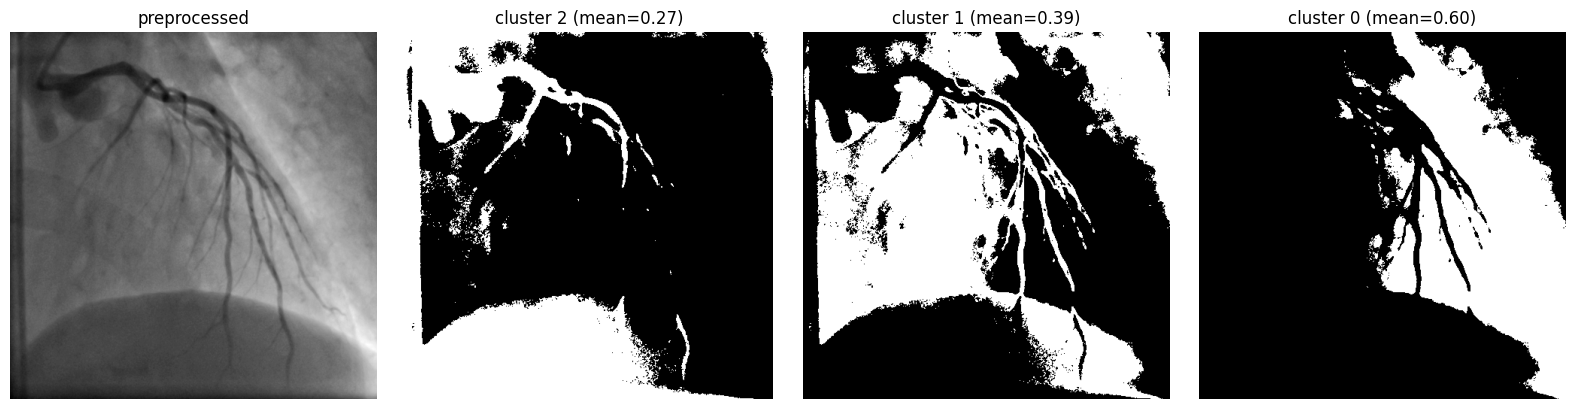

In [ ]:
mask3, gmm3 = apply_gmm(proc, n_components=3)  # 그냥 함수 재사용은 안 됨, 아래처럼

def apply_gmm_multi(proc_img, n_components=3):
    h, w = proc_img.shape
    pixels = proc_img.reshape(-1, 1)
    gmm = GaussianMixture(n_components=n_components, random_state=0)
    labels = gmm.fit_predict(pixels).reshape(h, w)
    means = gmm.means_.flatten()
    order = np.argsort(means)  # 어두운→밝은 순 cluster index
    return labels, means, order

labels, means, order = apply_gmm_multi(proc, n_components=3)
print("cluster 평균 밝기 (어두운→밝은):", means[order])

fig, axes = plt.subplots(1, len(order)+1, figsize=(4*(len(order)+1), 4))
axes[0].imshow(proc, cmap='gray'); axes[0].set_title("preprocessed"); axes[0].axis('off')
for i, cl in enumerate(order):
    axes[i+1].imshow(labels == cl, cmap='gray')
    axes[i+1].set_title(f"cluster {cl} (mean={means[cl]:.2f})")
    axes[i+1].axis('off')
plt.tight_layout()
plt.show()

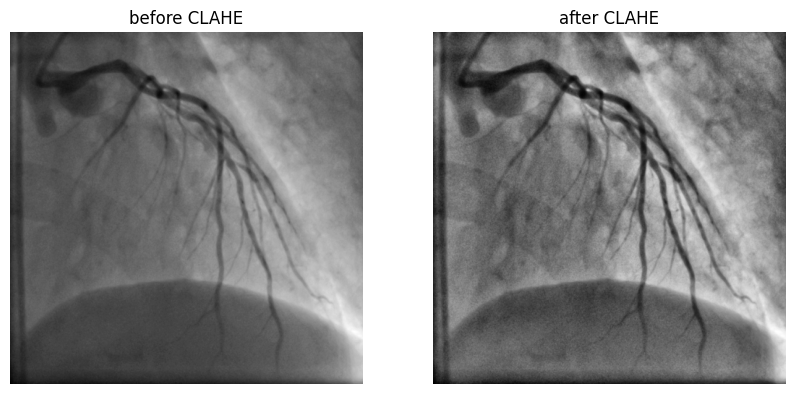

In [ ]:
def clahe_enhance(gray_uint8, clip_limit=3.0, tile_size=(8, 8)):
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_size)
    return clahe.apply(gray_uint8)

# proc은 0~1 float → uint8로 변환
proc_uint8 = (proc * 255).astype(np.uint8)
enhanced = clahe_enhance(proc_uint8)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(proc, cmap='gray')
axes[0].set_title("before CLAHE")
axes[0].axis('off')

axes[1].imshow(enhanced, cmap='gray')
axes[1].set_title("after CLAHE")
axes[1].axis('off')
plt.show()

CLAHE 후 cluster 평균 밝기: [0.32311047 0.45149303 0.67044718]


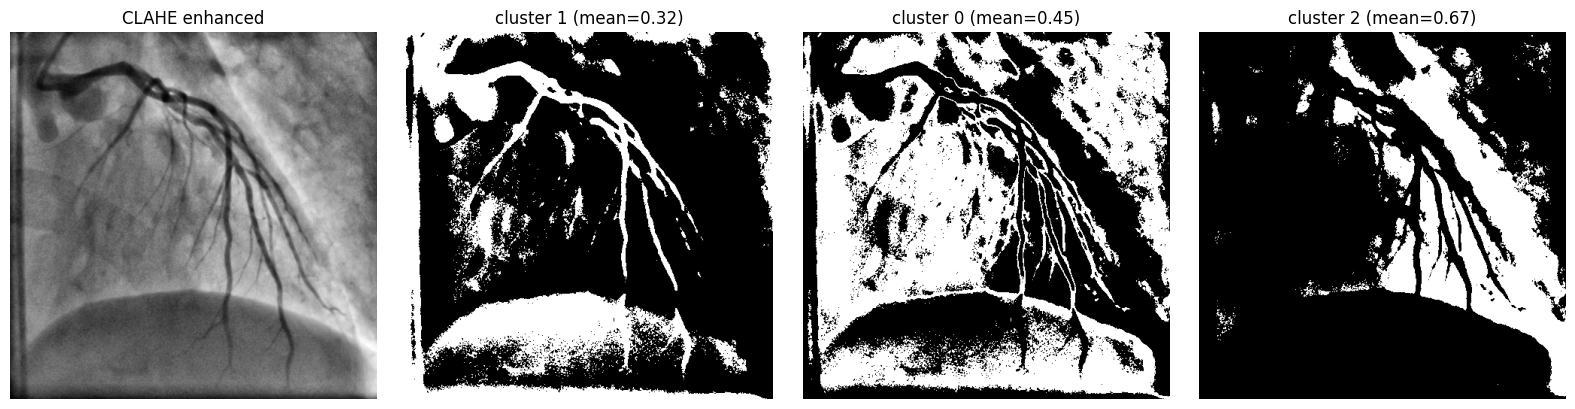

In [ ]:
enhanced_norm = enhanced.astype(np.float32) / 255.0

def apply_gmm_multi(proc_img, n_components=3):
    h, w = proc_img.shape
    pixels = proc_img.reshape(-1, 1)
    gmm = GaussianMixture(n_components=n_components, random_state=0)
    labels = gmm.fit_predict(pixels).reshape(h, w)
    means = gmm.means_.flatten()
    order = np.argsort(means)
    return labels, means, order

labels2, means2, order2 = apply_gmm_multi(enhanced_norm, n_components=3)
print("CLAHE 후 cluster 평균 밝기:", means2[order2])

fig, axes = plt.subplots(1, len(order2)+1, figsize=(4*(len(order2)+1), 4))
axes[0].imshow(enhanced_norm, cmap='gray')
axes[0].set_title("CLAHE enhanced")
axes[0].axis('off')
for i, cl in enumerate(order2):
    axes[i+1].imshow(labels2 == cl, cmap='gray')
    axes[i+1].set_title(f"cluster {cl} (mean={means2[cl]:.2f})")
    axes[i+1].axis('off')
plt.tight_layout()
plt.show()

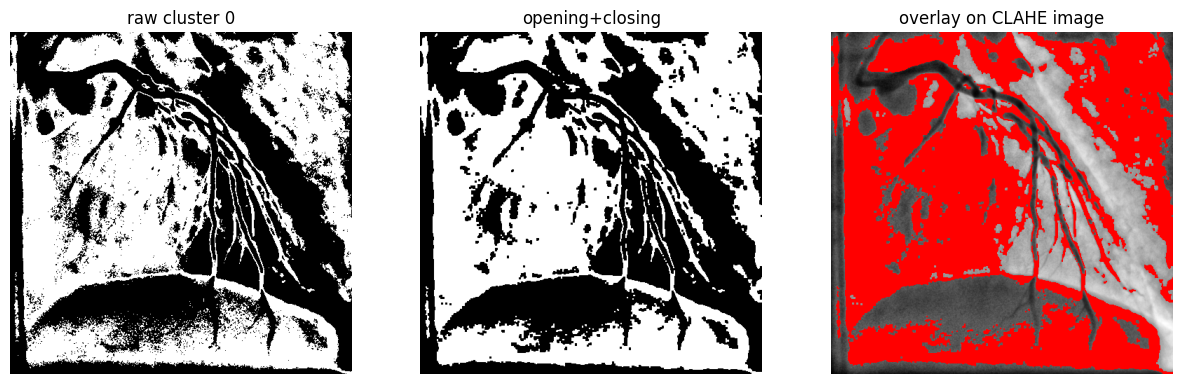

In [ ]:
vessel_mask = (labels2 == 0).astype(np.uint8) * 255  # cluster 0 = vessel

# 작은 노이즈 제거 (opening)
kernel_small = np.ones((2, 2), np.uint8)
cleaned = cv2.morphologyEx(vessel_mask, cv2.MORPH_OPEN, kernel_small)

# 끊긴 가지 살짝 이어주기 (closing)
kernel_close = np.ones((3, 3), np.uint8)
cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel_close)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(vessel_mask, cmap='gray'); axes[0].set_title("raw cluster 0"); axes[0].axis('off')
axes[1].imshow(cleaned, cmap='gray'); axes[1].set_title("opening+closing"); axes[1].axis('off')

overlay = cv2.cvtColor((enhanced_norm*255).astype(np.uint8), cv2.COLOR_GRAY2RGB)
overlay[cleaned > 0] = [255, 0, 0]
axes[2].imshow(overlay); axes[2].set_title("overlay on CLAHE image"); axes[2].axis('off')
plt.show()

0 255


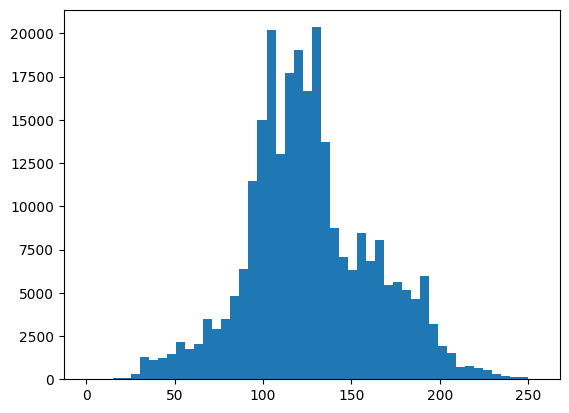

In [ ]:
print(gray.min(), gray.max())
plt.hist(gray.ravel(), bins=50)
plt.show()

In [ ]:
def simple_preprocess_v2(gray, thresh=20, margin_crop=5):
    ys, xs = np.where(gray > thresh)  # 10 -> 20 등으로 올려보기
    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()
    cropped = gray[y1:y2+1, x1:x2+1]

    # 그래도 남는 테두리를 고정 마진으로 한 번 더 깎기
    h, w = cropped.shape
    cropped = cropped[margin_crop:h-margin_crop, margin_crop:w-margin_crop]

    cropped = cropped.astype(np.float32)
    cropped = (cropped - cropped.min()) / (cropped.max() - cropped.min() + 1e-8)
    return cropped

In [ ]:
proc_uint8_blurred = cv2.medianBlur(proc_uint8, 3)
enhanced = clahe_enhance(proc_uint8_blurred)

In [ ]:
def remove_small_blobs(mask, min_area=30):
    n, labels_cc, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    cleaned = np.zeros_like(mask)
    for i in range(1, n):
        if stats[i, cv2.CC_STAT_AREA] >= min_area:
            cleaned[labels_cc == i] = 255
    return cleaned

cleaned_v3 = remove_small_blobs(cleaned, min_area=30)

In [ ]:
def remove_border_blobs(mask):
    h, w = mask.shape
    n, labels_cc, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    cleaned = np.zeros_like(mask)
    for i in range(1, n):
        x, y, ww, hh, area = stats[i]
        touches_border = (x == 0 or y == 0 or x + ww == w or y + hh == h)
        spans_wide = ww > w * 0.8 or hh > h * 0.8
        if touches_border and spans_wide:
            continue
        cleaned[labels_cc == i] = 255
    return cleaned


def remove_small_blobs(mask, min_area=30):
    n, labels_cc, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    cleaned = np.zeros_like(mask)
    for i in range(1, n):
        if stats[i, cv2.CC_STAT_AREA] >= min_area:
            cleaned[labels_cc == i] = 255
    return cleaned

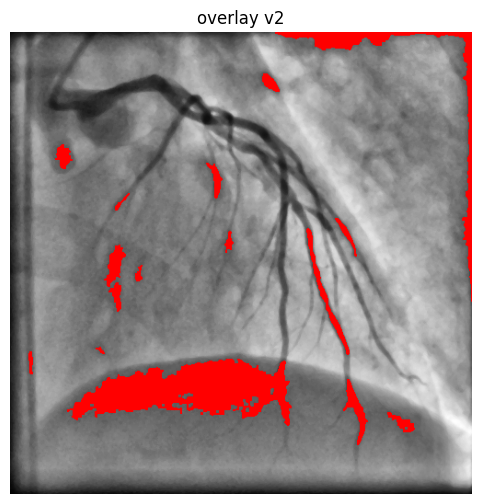

In [ ]:
# 1) crop (threshold 올리고 margin 추가)
proc = simple_preprocess_v2(gray, thresh=20, margin_crop=5)

# 2) blur 살짝
proc_uint8 = (proc * 255).astype(np.uint8)
proc_uint8 = cv2.medianBlur(proc_uint8, 3)

# 3) CLAHE
enhanced = clahe_enhance(proc_uint8)
enhanced_norm = enhanced.astype(np.float32) / 255.0

# 4) GMM (3-cluster, 가장 어두운 것)
labels2, means2, order2 = apply_gmm_multi(enhanced_norm, n_components=3)
vessel_mask = (labels2 == order2[0]).astype(np.uint8) * 255

# 5) morphology
kernel_small = np.ones((2,2), np.uint8)
kernel_close = np.ones((3,3), np.uint8)
cleaned = cv2.morphologyEx(vessel_mask, cv2.MORPH_OPEN, kernel_small)
cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel_close)

# 6) 후처리 (테두리 덩어리 제거 + 작은 노이즈 제거)
cleaned = remove_border_blobs(cleaned)
cleaned = remove_small_blobs(cleaned, min_area=30)

# 7) overlay
overlay = cv2.cvtColor((enhanced_norm*255).astype(np.uint8), cv2.COLOR_GRAY2RGB)
overlay[cleaned > 0] = [255, 0, 0]

plt.figure(figsize=(6,6))
plt.imshow(overlay); plt.axis('off'); plt.title("overlay v2")
plt.show()

In [ ]:
proc = simple_preprocess_v2(gray, thresh=25, margin_crop=8)  # margin 늘림

proc_uint8 = (proc * 255).astype(np.uint8)
# median blur 제거! CLAHE 바로
enhanced = clahe_enhance(proc_uint8, clip_limit=3.0, tile_size=(8,8))
enhanced_norm = enhanced.astype(np.float32) / 255.0

In [ ]:
labels2, means2, order2 = apply_gmm_multi(enhanced_norm, n_components=3)
vessel_mask = (labels2 == order2[0]).astype(np.uint8) * 255

In [ ]:
def remove_blob_like_regions(mask, min_area=15, max_fill_ratio=0.55):
    n, labels_cc, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    cleaned = np.zeros_like(mask)
    for i in range(1, n):
        x, y, w, h, area = stats[i]
        if area < min_area:
            continue  # 너무 작은 노이즈 점
        fill_ratio = area / (w * h + 1e-6)
        if fill_ratio > max_fill_ratio:
            continue  # bbox를 꽉 채우는 뭉친 덩어리 -> 제거
        cleaned[labels_cc == i] = 255
    return cleaned

cleaned = cv2.morphologyEx(vessel_mask, cv2.MORPH_OPEN, np.ones((2,2), np.uint8))
cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, np.ones((3,3), np.uint8))
cleaned = remove_border_blobs(cleaned)
cleaned = remove_blob_like_regions(cleaned, min_area=15, max_fill_ratio=0.55)

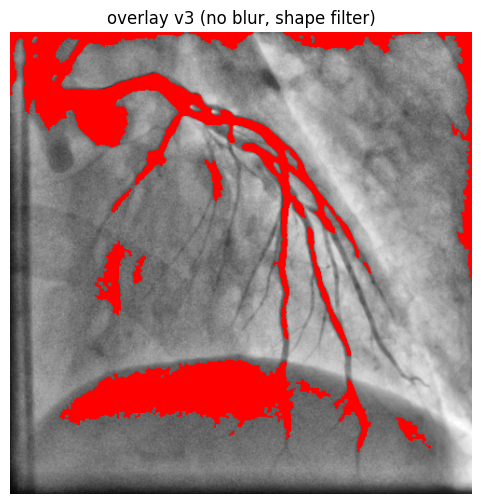

In [ ]:
overlay = cv2.cvtColor((enhanced_norm*255).astype(np.uint8), cv2.COLOR_GRAY2RGB)
overlay[cleaned > 0] = [255, 0, 0]

plt.figure(figsize=(6,6))
plt.imshow(overlay); plt.axis('off'); plt.title("overlay v3 (no blur, shape filter)")
plt.show()

In [ ]:
proc = simple_preprocess_v2(gray, thresh=25, margin_crop=12)  # 8 -> 12

In [ ]:
def crop_roi_top(mask_or_img, top_ratio=0.85):
    h = mask_or_img.shape[0]
    result = mask_or_img.copy()
    result[int(h*top_ratio):, :] = 0
    return result

cleaned_final = crop_roi_top(cleaned, top_ratio=0.85)

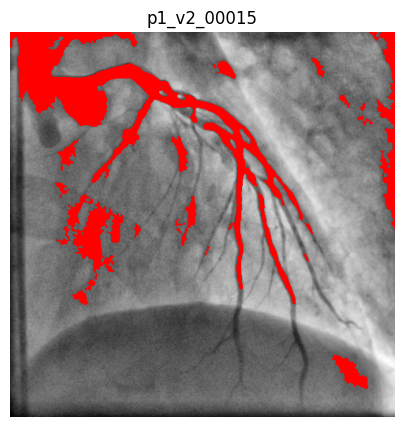

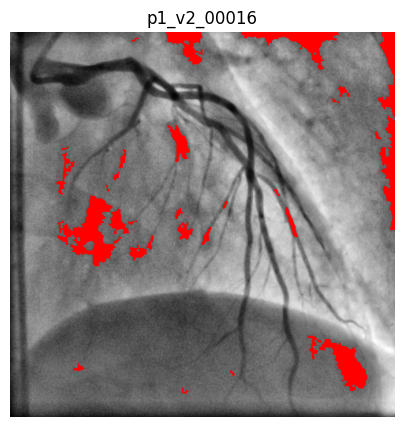

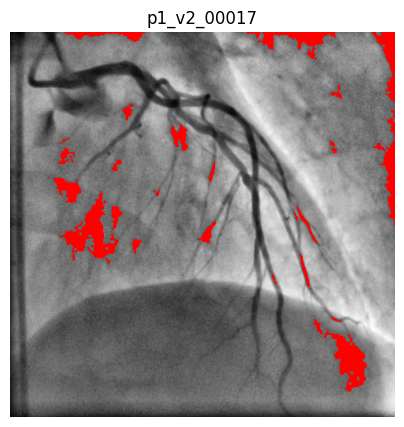

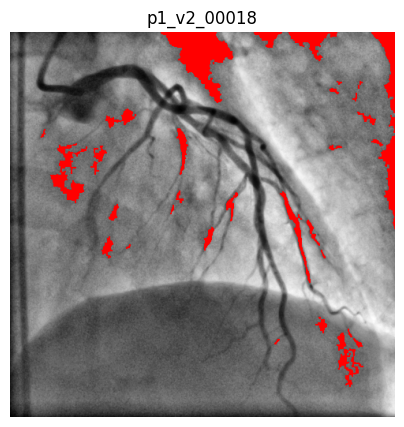

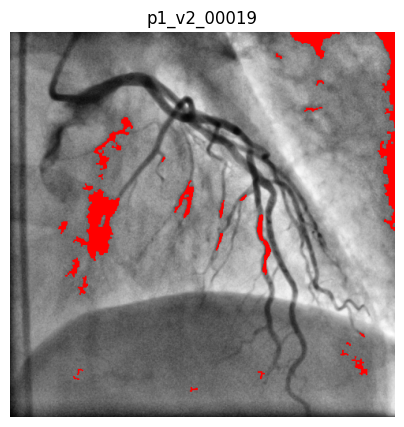

In [ ]:
sample_paths_check = gt_files[:5]  # 이전에 썼던 lesion 프레임들

for gt_file in sample_paths_check:
    fid = gt_file.stem
    ip = Path("/content/cadica_dataset/CADICA/selectedVideos/p1/v2/input") / f"{fid}.png"
    g = cv2.imread(str(ip), cv2.IMREAD_GRAYSCALE)

    p = simple_preprocess_v2(g, thresh=25, margin_crop=12)
    p_u8 = (p * 255).astype(np.uint8)
    e = clahe_enhance(p_u8)
    e_norm = e.astype(np.float32) / 255.0

    lb, mn, od = apply_gmm_multi(e_norm, n_components=3)
    vm = (lb == od[0]).astype(np.uint8) * 255
    c = cv2.morphologyEx(vm, cv2.MORPH_OPEN, np.ones((2,2), np.uint8))
    c = cv2.morphologyEx(c, cv2.MORPH_CLOSE, np.ones((3,3), np.uint8))
    c = remove_border_blobs(c)
    c = remove_blob_like_regions(c, min_area=15, max_fill_ratio=0.55)

    ov = cv2.cvtColor((e_norm*255).astype(np.uint8), cv2.COLOR_GRAY2RGB)
    ov[c > 0] = [255, 0, 0]

    plt.figure(figsize=(5,5))
    plt.imshow(ov); plt.axis('off'); plt.title(fid)
    plt.show()

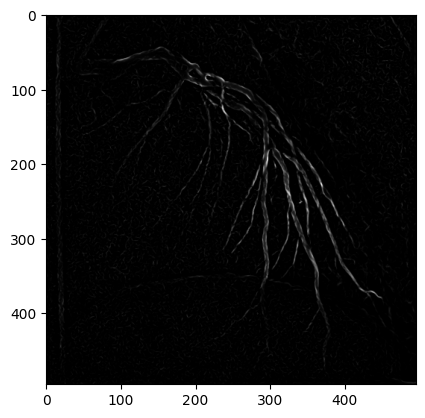

In [ ]:
from skimage.filters import frangi

vesselness = frangi(enhanced_norm, sigmas=range(1, 4), black_ridges=True)
# black_ridges=True: 어두운 선(우리 혈관처럼) 강조
plt.imshow(vesselness, cmap='gray')
plt.show()

In [ ]:
# @title 전처리
from pathlib import Path
import pandas as pd

base = Path("/content/cadica_dataset/CADICA/selectedVideos")

rows = []
for p_dir in sorted(base.glob("p*")):
    if not p_dir.is_dir():
        continue
    patient_id = p_dir.name

    lesion_file = p_dir / "lesionVideos.txt"
    nonlesion_file = p_dir / "nonlesionVideos.txt"

    lesion_vids = lesion_file.read_text().split() if lesion_file.exists() else []
    nonlesion_vids = nonlesion_file.read_text().split() if nonlesion_file.exists() else []

    for v in lesion_vids:
        rows.append({"patient_id": patient_id, "video_id": v, "label": "lesion"})
    for v in nonlesion_vids:
        rows.append({"patient_id": patient_id, "video_id": v, "label": "non-lesion"})

df = pd.DataFrame(rows)
print("총 video 수:", len(df))
print(df.head())
print(df.label.value_counts())

총 video 수: 382
  patient_id video_id       label
0         p1       v2      lesion
1         p1       v3      lesion
2         p1      v10      lesion
3         p1      v11      lesion
4         p1       v1  non-lesion
label
lesion        269
non-lesion    113
Name: count, dtype: int64


In [ ]:
import json

proj_path = base / "CADICAprojections.json"
with open(proj_path) as f:
    projections = json.load(f)

# 구조 확인 (처음 보는 형식이라 먼저 찍어봐야 함)
print(type(projections))
if isinstance(projections, dict):
    first_key = list(projections.keys())[0]
    print(first_key, "->", projections[first_key])
elif isinstance(projections, list):
    print(projections[0])

<class 'dict'>
videosLCA -> ['p1_v1', 'p1_v2', 'p1_v3', 'p1_v9', 'p1_v10', 'p1_v11', 'p2_v10', 'p2_v11', 'p3_v1', 'p3_v3', 'p4_v1', 'p4_v2', 'p4_v3', 'p4_v5', 'p5_v1', 'p5_v2', 'p5_v3', 'p6_v4', 'p6_v5', 'p6_v6', 'p6_v8', 'p7_v6', 'p7_v7', 'p7_v10', 'p8_v11', 'p8_v12', 'p9_v4', 'p9_v5', 'p9_v6', 'p10_v1', 'p10_v2', 'p10_v3', 'p10_v5', 'p11_v3', 'p11_v7', 'p12_v1', 'p12_v2', 'p12_v11', 'p12_v16', 'p12_v17', 'p12_v22', 'p12_v27', 'p13_v5', 'p13_v14', 'p14_v10', 'p15_v4', 'p15_v6', 'p16_v20', 'p16_v27', 'p17_v6', 'p17_v10', 'p17_v13', 'p17_v16', 'p18_v2', 'p18_v4', 'p18_v5', 'p18_v6', 'p18_v7', 'p18_v8', 'p18_v9', 'p18_v12', 'p19_v4', 'p19_v9', 'p19_v12', 'p20_v2', 'p20_v3', 'p20_v4', 'p20_v7', 'p20_v8', 'p20_v11', 'p20_v22', 'p20_v23', 'p21_v2', 'p21_v3', 'p21_v5', 'p21_v8', 'p21_v11', 'p22_v5', 'p22_v6', 'p22_v14', 'p22_v21', 'p22_v22', 'p22_v24', 'p22_v26', 'p22_v30', 'p22_v32', 'p22_v34', 'p22_v37', 'p23_v6', 'p23_v15', 'p24_v2', 'p24_v3', 'p24_v4', 'p24_v5', 'p24_v9', 'p24_v12', 'p24

In [ ]:
# @title 뷰 매핑
print("전체 키:", list(projections.keys()))

In [ ]:
lca_set = set(projections.get("videosLCA", []))
rca_set = set(projections.get("videosRCA", []))

print("LCA 개수:", len(lca_set))
print("RCA 개수:", len(rca_set))
print("겹치는 것 있나:", len(lca_set & rca_set))  # 0이어야 정상

LCA 개수: 216
RCA 개수: 118
겹치는 것 있나: 0


In [ ]:
def get_view(row):
    key = f"{row.patient_id}_{row.video_id}"
    if key in lca_set:
        return "LCA"
    elif key in rca_set:
        return "RCA"
    else:
        return "unknown"

df["view"] = df.apply(get_view, axis=1)
print(df.view.value_counts())

view
LCA        216
RCA        118
unknown     48
Name: count, dtype: int64


In [ ]:
print("unknown 제외 총 개수:", len(df[df.view != "unknown"]))
print(df[df.view != "unknown"].label.value_counts())

unknown 제외 총 개수: 334
label
lesion        246
non-lesion     88
Name: count, dtype: int64


In [ ]:
df_final = df[df.view != "unknown"].copy().reset_index(drop=True)
print("최종 사용할 video 수:", len(df_final))
print(df_final.view.value_counts())
print(pd.crosstab(df_final.view, df_final.label))

최종 사용할 video 수: 334
view
LCA    216
RCA    118
Name: count, dtype: int64
label  lesion  non-lesion
view                     
LCA       158          58
RCA        88          30


In [ ]:
def get_video_stats(patient_id, video_id):
    v_dir = base / patient_id / video_id
    input_dir = v_dir / "input"
    n_frames = len(list(input_dir.glob("*.png"))) if input_dir.exists() else 0
    has_gt = (v_dir / "groundtruth").exists()
    return n_frames, has_gt

stats = df_final.apply(lambda r: get_video_stats(r.patient_id, r.video_id), axis=1)
df_final["n_frames"] = stats.apply(lambda x: x[0])
df_final["has_groundtruth"] = stats.apply(lambda x: x[1])

print(df_final.head())
print("총 프레임 수:", df_final.n_frames.sum())

  patient_id video_id       label view  n_frames  has_groundtruth
0         p1       v2      lesion  LCA        56             True
1         p1       v3      lesion  LCA        44             True
2         p1      v10      lesion  LCA        56             True
3         p1      v11      lesion  LCA        44             True
4         p1       v1  non-lesion  LCA        55            False
총 프레임 수: 15799


In [ ]:
import numpy as np

np.random.seed(42)

patients = df_final.patient_id.unique()
np.random.shuffle(patients)

n = len(patients)
n_train = int(n * 0.8)
n_val = int(n * 0.1)

train_patients = set(patients[:n_train])
val_patients = set(patients[n_train:n_train+n_val])
test_patients = set(patients[n_train+n_val:])

def assign_split(pid):
    if pid in train_patients:
        return "train"
    elif pid in val_patients:
        return "val"
    else:
        return "test"

df_final["split"] = df_final.patient_id.apply(assign_split)

print(df_final.split.value_counts())
print("=== label 분포 ===")
print(pd.crosstab(df_final.split, df_final.label))
print("=== view 분포 ===")
print(pd.crosstab(df_final.split, df_final.view))

split
train    264
test      45
val       25
Name: count, dtype: int64
=== label 분포 ===
label  lesion  non-lesion
split                    
test       27          18
train     206          58
val        13          12
=== view 분포 ===
view   LCA  RCA
split          
test    27   18
train  173   91
val     16    9


 train/val/test 각각도 non-lesion이 약 26% 근처여야...

val/test에 non-lesion이 과하게 몰려있으면, val/test 성능이 train에서 본 분포랑 다른 상황을 평가  
모델은 train에서 non-lesion을 상대적으로 덜 보고 학습했는데, test에서는 non-lesion을 훨씬 많이 만나서 → 실제보다 성능이 나쁘게(또는 우연히 좋게) 나올 수 있음  
non-lesion이 원래 소수 클래스라 민감한 부분이라, 이 불균형이 split마다 다르면 결과 해석이 꼬임  

In [ ]:
def try_split(seed, df, train_ratio=0.8, val_ratio=0.1):
    np.random.seed(seed)
    patients = df.patient_id.unique().copy()
    np.random.shuffle(patients)

    n = len(patients)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)

    train_p = set(patients[:n_train])
    val_p = set(patients[n_train:n_train+n_val])
    test_p = set(patients[n_train+n_val:])

    def assign(pid):
        if pid in train_p: return "train"
        elif pid in val_p: return "val"
        else: return "test"

    split_col = df.patient_id.apply(assign)
    return split_col

overall_ratio = (df_final.label == "non-lesion").mean()

best_seed = None
best_score = float("inf")

for seed in range(200):
    split_col = try_split(seed, df_final)
    tmp = df_final.copy()
    tmp["split"] = split_col

    score = 0
    for s in ["train", "val", "test"]:
        subset = tmp[tmp.split == s]
        if len(subset) == 0:
            score += 999  # 비어있으면 나쁜 점수
            continue
        ratio = (subset.label == "non-lesion").mean()
        score += abs(ratio - overall_ratio)  # 전체 비율과의 차이 누적

    if score < best_score:
        best_score = score
        best_seed = seed

print("최적 seed:", best_seed, "score:", best_score)

최적 seed: 77 score: 0.019896451459524622


In [ ]:
df_final["split"] = try_split(best_seed, df_final)

print(df_final.split.value_counts())
print("=== label 비율 (전체 26% 기준) ===")
for s in ["train", "val", "test"]:
    subset = df_final[df_final.split == s]
    ratio = (subset.label == "non-lesion").mean()
    print(f"{s}: non-lesion 비율 = {ratio:.2%} (n={len(subset)})")

print("=== view 분포 ===")
print(pd.crosstab(df_final.split, df_final.view))

split
train    271
val       36
test      27
Name: count, dtype: int64
=== label 비율 (전체 26% 기준) ===
train: non-lesion 비율 = 26.57% (n=271)
val: non-lesion 비율 = 25.00% (n=36)
test: non-lesion 비율 = 25.93% (n=27)
=== view 분포 ===
view   LCA  RCA
split          
test    19    8
train  169  102
val     28    8


In [ ]:
save_path = "/content/drive/MyDrive/🐥new_2_project/04_DL_project/08_전처리/common_split.csv"
df_final.to_csv(save_path, index=False)

print(f"저장 완료: {save_path}")
print(f"총 {len(df_final)}개 video / {df_final.patient_id.nunique()}명 환자 / 총 {df_final.n_frames.sum()}프레임")
print(df_final.split.value_counts())

저장 완료: /content/drive/MyDrive/🐥new_2_project/04_DL_project/08_전처리/common_split.csv
총 334개 video / 42명 환자 / 총 15799프레임
split
train    271
val       36
test      27
Name: count, dtype: int64


In [ ]:
check = pd.read_csv(save_path)
print(check.shape)
check.head()

(334, 7)


,patient_id,video_id,label,view,n_frames,has_groundtruth,split
0,p1,v2,lesion,LCA,56,True,train
1,p1,v3,lesion,LCA,44,True,train
2,p1,v10,lesion,LCA,56,True,train
3,p1,v11,lesion,LCA,44,True,train
4,p1,v1,non-lesion,LCA,55,False,train
